# **Tutorial 2: The cortical rate-scale representation with aud2cor**


The auditory system does not extract information exclusively from the frequency analysis performed in the cochlea. Instead, in higher-level areas, a spectrotemporal analysis is thought to take place. 

`wav2aud` which builds the auditory spectrogram for a signal, but `aud2cor` moves one step further by exposing the modulation structure of that representation. This function aims to mimic the spectrotemporal analysis performed in the mammalian primary auditory cortex (A1). The model is based on physiological data rather than a biophysical approach. \[[1](#References)\]


## **Theoretical background**

A 2-D FFT is taken because the auditory spectrogram is a 2-D signal: one axis is time and the other is frequency. The FFT makes it possible to see how energy is distributed across temporal and spectral modulation patterns.

Padding is used so that the FFT can be computed on a power-of-two size, which makes the implementation faster and more stable. It also helps avoid wrap-around artifacts when the transform is later inverted.

Only half of the spatial spectrum is stored initially because the input is real-valued and its Fourier transform is symmetric. Keeping only one half is enough for the later steps and reduces memory use.

Temporal modulation filtering applies a set of filters along the time axis to separate slow from fast changes. These filters are parameterized by rate, which describes how quickly a modulation repeats over time.

Positive and negative rates correspond to modulations with opposite phase directions. In practice, the implementation keeps both so that the transformation can represent motion in either direction.

The first inverse FFT returns the result to the time domain after temporal filtering. This step converts the filtered modulation representation back into a form that can be combined with spectral processing.

Spectral modulation filtering is then applied along the frequency axis. This separates broad and narrow modulation patterns across frequency channels.

A second inverse FFT brings the result back into the frequency domain. At that point, the representation has been transformed into a cortical rate-scale map.

The representation becomes complex-valued because the filters are defined with phase information. This phase is important for preserving the structure of the modulation pattern, not just its magnitude.

Separable filtering makes the computation efficient because the temporal and spectral operations can be applied one axis at a time. That avoids a fully 2-D filter bank and keeps the implementation much lighter.

The processing order is time-first and then frequency-second because the algorithm first extracts temporal modulation structure and then uses that result to extract spectral modulation structure. This mirrors the idea that rate and scale are two different layers of analysis.


## **Using aud2cor**

For this tutorial, we will load an audio file from one of the examples and create an audiogram, as in Tutorial 1. We will then pass that result to `aud2cor`.

Parameters specific to `aud2cor` are:

- `tp_margin`: controls how much temporal margin is added around the representation.
- `sp_margin`: controls how much spectral margin is added around the representation.
- `bandpass`: changes the passband of the filters.
- `tpfilt_cf`: defines the center frequencies of the temporal modulation filters.
- `spfilt_ripples`: defines the center frequencies of the spectral modulation filters.
- `fname`: if given, writes the complex output to a binary file.

The parameters for `wav2aud` can still be passed in, and these will be used to write the header of the binary file.

For most exploratory work, the defaults are a good place to start.


### **Step 1: Generate audiogram**
Using the same steps as in Tutorial 1, we can choose an example sound using the dropdown menu and generate the audiogram using `wav2aud`. 

In [1]:
from neural_audio.examples.sounds.load import load_sound_file_paths2
import soundfile as soundf
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display, Audio

# Get list of sound files 
sound_files = load_sound_file_paths2()
sound_file_names = [Path(file).name for file in sound_files]

# Create dropwdown widget to select and play sound file
dropdown = widgets.Dropdown(options=sound_file_names, description='Sound file:')
audio_player = widgets.Output()
sound_file_path = sound_files[1]

def on_change(change):
    if change['type'] == 'change' and change['name'] == 'value':
        global sound_file_path
        for file in sound_files:
            if Path(file).name == change['new']: sound_file_path = file
        audio_player.clear_output()
        with audio_player:
            display(Audio(str(sound_file_path), autoplay=False))

dropdown.observe(on_change)
dropdown.value = sound_file_names[1]  # Set default value to the first sound file
display(dropdown, audio_player)

Dropdown(description='Sound file:', index=1, options=('cardboard tapping.wav', 'cardboard whirling.wav', 'gees…

Output()

Audiogram shape == [128 frequencies, 750 time points]


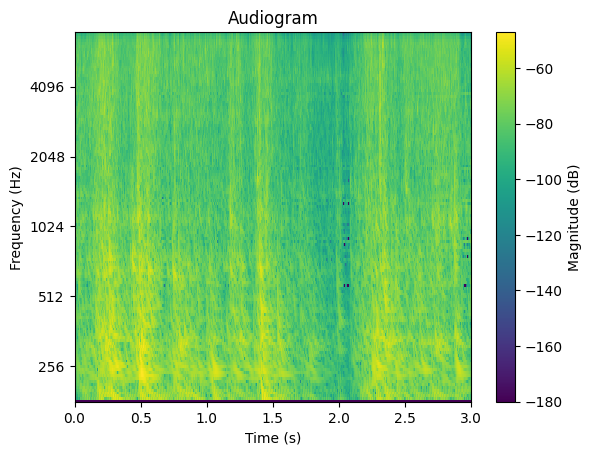

In [2]:
from neural_audio.wav2aud import wav2aud
from neural_audio.utils.visualize_outputs import plot_spectrogram

# Compute an audiogram with default parameters
waveform, sampling_rate = soundf.read(sound_file_path)
time_points_audiogram, frequencies_audiogram, audiogram  = wav2aud(waveform)

print(f"Audiogram shape == [{audiogram.shape[0]} frequencies, {audiogram.shape[1]} time points]")

# For convenience, visualize the output
plot_spectrogram(audiogram, time_points_audiogram, frequencies_audiogram, title='Audiogram')


### **Step 2: Generate cortical representation**
To get the correct output dimensions, the **transpose** of the audiogram must be passed as input to `aud2cor`. Since we used default parameters for `wav2aud`, it is safe to also use the defaults for `aud2cor`. Note that **this step is far more computationally intensive and may take a few minutes**.

In [ ]:
from neural_audio.aud2cor import aud2cor
cr = aud2cor(audiogram.T) # NOTE that the transpose is used here
print(f"Cortical representation shape: {cr.shape}")

num_scales, num_rates, n_time, n_freq = cr.shape
print(f"Number of scales: {num_scales}")
print(f"Number of rate channels: {num_rates}")
print(f"Time frames: {n_time}")
print(f"Frequency frames: {n_freq}")

Cortical representation shape: (32, 64, 750, 128)
Number of scales: 32
Number of rate channels: 64
Time frames: 750
Frequency frames: 128


### **Step 3: Visualization**
The output of `aud2cor` has four dimensions: scale, rate, time, and frequency. Because of this, it is useful to create 2D projections along specific axes. We can use the function `plot_cr_projection` from utils to do so. It requires two arguments:
- `cr` - The cortical representation (output of aud2cor), an array [scale x rate x time x frequency]
- `rates` - The rate vector used to construct the cortical representation


In [10]:
frequencies_audiogram.shape

(128,)

In [ ]:
import numpy as np
from neural_audio.utils.visualize_outputs import plot_cr_projection

rates = 2 ** np.linspace(np.log2(0.5), np.log2(128), 32)
scales = 2 ** np.linspace(np.log2(1/5), np.log2(10), 32)
plot_cr_projection(cr, rates, scales=scales, frequencies=frequencies_audiogram)

## **About the filters**

The two filter generators are `gen_cort` and `gen_corf`. The first builds the temporal modulation filters, while the second builds the spectral modulation filters. In the implementation, `gen_cort` is causal, meaning it uses only past information to define the filter response, while `gen_corf` is symmetric, meaning it treats the modulation pattern equally on both sides of the center point.

Analytic filters are used because they carry phase information in a compact way. This makes it possible to preserve the complex structure of the modulation response rather than discarding it as a purely real-valued envelope.

Positive and negative rates are generated by pairing a filter with its complex-conjugate counterpart. This gives the representation both directions of temporal modulation, which is important for capturing phase-sensitive structure.


## **Theoretical background**

A 2-D FFT is taken because the auditory spectrogram is a 2-D signal: one axis is time and the other is frequency. The FFT makes it possible to see how energy is distributed across temporal and spectral modulation patterns.

Padding is used so that the FFT can be computed on a power-of-two size, which makes the implementation faster and more stable. It also helps avoid wrap-around artifacts when the transform is later inverted.

Only half of the spatial spectrum is stored initially because the input is real-valued and its Fourier transform is symmetric. Keeping only one half is enough for the later steps and reduces memory use.

Temporal modulation filtering applies a set of filters along the time axis to separate slow from fast changes. These filters are parameterized by rate, which describes how quickly a modulation repeats over time.

Positive and negative rates correspond to modulations with opposite phase directions. In practice, the implementation keeps both so that the transformation can represent motion in either direction.

The first inverse FFT returns the result to the time domain after temporal filtering. This step converts the filtered modulation representation back into a form that can be combined with spectral processing.

Spectral modulation filtering is then applied along the frequency axis. This separates broad and narrow modulation patterns across frequency channels.

A second inverse FFT brings the result back into the frequency domain. At that point, the representation has been transformed into a cortical rate-scale map.

The representation becomes complex-valued because the filters are defined with phase information. This phase is important for preserving the structure of the modulation pattern, not just its magnitude.

Separable filtering makes the computation efficient because the temporal and spectral operations can be applied one axis at a time. That avoids a fully 2-D filter bank and keeps the implementation much lighter.

The processing order is time-first and then frequency-second because the algorithm first extracts temporal modulation structure and then uses that result to extract spectral modulation structure. This mirrors the idea that rate and scale are two different layers of analysis.


## **Using aud2cor**

We now run `aud2cor` on an existing audiogram. For this tutorial, we will load an audio file and create an audiogram with `wav2aud` first, and then pass that result to `aud2cor`.

The parameters that are new compared with `wav2aud` are `tp_margin`, `sp_margin`, `bandpass`, `tpfilt_cf`, `spfilt_ripples`, and `fname`. The first two control the amount of margin added around the representation, while `bandpass` changes the filter passband. The arrays `tpfilt_cf` and `spfilt_ripples` define the rate and scale filter centers, and `fname` writes the output to a binary file if you provide a name.


# References
[1] Chi, Taishih & Ru, Powen & Shamma, Shihab (2005),
        "Multiresolution spectrotemporal analysis of complex sounds" ,
        The Journal of the Acoustical Society of America, 118, 887-906, 
        10.1121/1.1945807